In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import hdbscan
from sklearn.cluster import HDBSCAN
import umap
from collections import Counter


In [ ]:
PCA_rule_of_thumb=pd.read_csv('PCA_rule_of_thumb.csv')
PCA_kaiser=pd.read_csv('PCA_kaiser.csv')
PCA_parallel=pd.read_csv('PCA_parallel.csv')
UMAP_euclidean=pd.read_csv('UMAP_euclidean.csv')
UMAP_cosine=pd.read_csv('UMAP_cosine.csv')
UMAP_highdim=pd.read_csv('UMAP_highdim.csv')

In [ ]:
UMAP_clu=pd.read_csv('UMAP_clu.csv')
UMAP_euclidean=pd.read_csv('UMAP_euclidean.csv')

In [ ]:
#ricalca struttura di clustering with UMAP quando scrivi sta parte

In [ ]:
features = PCA_parallel.drop(columns=['user_uid', 'original_labels']).copy()
min_samples=[4,5,6,7,8,9,10,15,20,25,30,35,40,50,60,70,80,90,100,125,150,175,200,250,300,350,400]
for i in min_samples:
  hdbscan_model = hdbscan.HDBSCAN(min_samples=i, min_cluster_size=430)
  labels = hdbscan_model.fit_predict(features)

  # Count observations in each cluster
  cluster_counts = Counter(labels)
  num_noise_points = cluster_counts[-1] if -1 in cluster_counts else 0

  # Print results
  print(f"min_samples: {i}")
  print(f"Number of clusters: {np.unique(labels).tolist()}")
  print(f"Observations per cluster: {dict((k, v) for k, v in cluster_counts.items() if k != -1)}")
  print(f"Number of noise points: {num_noise_points}")
  print("")

In [ ]:

features = PCA_parallel.drop(columns=['user_uid', 'original_labels']).copy()

labels = HDBSCAN(min_samples=4, min_cluster_size=430).fit_predict(features)

# Count observations in each cluster
cluster_counts = Counter(labels)
num_noise_points = cluster_counts[-1] if -1 in cluster_counts else 0

# Print results
print(f"Number of clusters: {np.unique(labels).tolist()}")
print(f"Observations per cluster: {dict((k, v) for k, v in cluster_counts.items() if k != -1)}")
print(f"Number of noise points: {num_noise_points}")

Number of clusters: [-1, 0, 1, 2, 3, 4, 5, 6, 7]
Observations per cluster: {np.int64(4): 3650, np.int64(0): 1742, np.int64(2): 498, np.int64(3): 811, np.int64(6): 900, np.int64(1): 1549, np.int64(5): 524, np.int64(7): 672}
Number of noise points: 39488


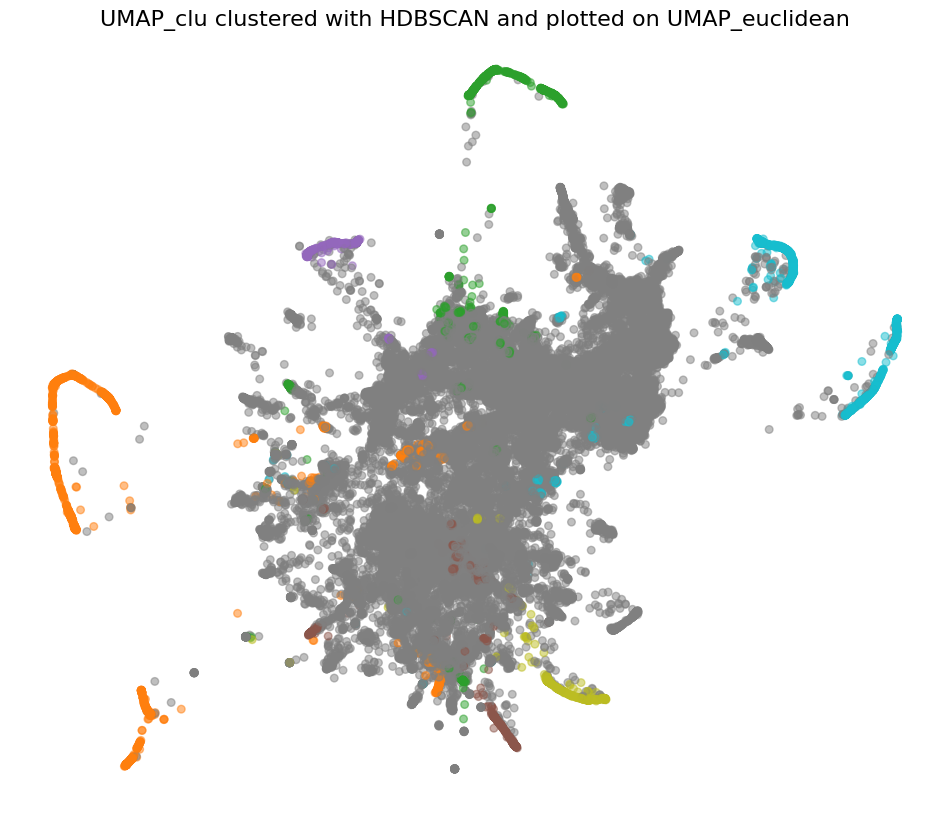

In [ ]:

# Assuming hdbscan_labels and UMAP_euclidean are already defined

# Get unique labels and count clusters (excluding noise)
unique_labels = np.unique(labels)
num_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

# Create a colormap for valid clusters (excluding noise)
cluster_cmap = plt.get_cmap("tab10", num_clusters)  # Change colormap if needed

# Generate colors for clusters, mapping -1 to gray
color_dict = {label: cluster_cmap(i) for i, label in enumerate(unique_labels) if label != -1}
color_dict[-1] = "gray"  # Explicitly assign gray to noise points

# Convert labels to corresponding colors (store as a list instead of NumPy array)
color = [color_dict[label] for label in labels]

# Extract UMAP coordinates
x, y = UMAP_euclidean['UMAP_1'], UMAP_euclidean['UMAP_2']

# Plot the embedding
plt.figure(figsize=(12, 10))

# Scatter plot with colors
plt.scatter(x, y, c=color, s=30, alpha=0.5)

# Set title and labels
plt.title("PCA_parallel clustered with HDBSCAN and plotted on UMAP_euclidean", fontsize=16)
plt.xlabel("UMAP 1", fontsize=14)
plt.ylabel("UMAP 2", fontsize=14)

# Hide axes for a cleaner look
plt.axis('off')

# Show the plot
plt.show()

In [ ]:
# Import the sample containing also the original labels
df = pd.read_csv('/content/sample_with_labels.csv')
df.fillna(0, inplace=True)

# Temporarily remove 'user_uid'
features_df = df.drop(columns=['user_uid', 'label_pred_desc'])

features_df = pd.DataFrame(features_df, columns=df.columns.drop(['user_uid', 'label_pred_desc']))

In [ ]:
# Initialize UMAP with current parameters
reducer = umap.UMAP(n_neighbors= 80, min_dist= 0.05, n_components= 10, metric ='euclidean')

# Fit and transform the data
UMAP_clu = reducer.fit_transform(features_df)

# Convert UMAP result to a DataFrame
UMAP_clu = pd.DataFrame(UMAP_clu, columns=[f'UMAP_{i+1}' for i in range(UMAP_clu.shape[1])])

# Add additional columns from the original DataFrame
UMAP_clu['user_uid'] = df['user_uid'].reset_index(drop=True)
UMAP_clu['cluster'] = df['label_pred_desc'].reset_index(drop=True)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
UMAP_clu.to_csv('UMAP_clu.csv', index=False)

In [ ]:
features = UMAP_clu.drop(columns=['user_uid', 'cluster']).copy()
min_samples=[4,5,6,7,8,9,10,15,20,25,30,35,40,50,60,70,80,90,100,125,150,175,200,250,300,350,400]
for i in min_samples:
  hdbscan_model = hdbscan.HDBSCAN(min_samples=i, min_cluster_size=430)
  labels = hdbscan_model.fit_predict(features)

  # Count observations in each cluster
  cluster_counts = Counter(labels)
  num_noise_points = cluster_counts[-1] if -1 in cluster_counts else 0

  # Print results
  print(f"min_samples: {i}")
  print(f"Number of clusters: {np.unique(labels).tolist()}")
  print(f"Observations per cluster: {dict((k, v) for k, v in cluster_counts.items() if k != -1)}")
  print(f"Number of noise points: {num_noise_points}")
  print("")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


min_samples: 4
Number of clusters: [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Observations per cluster: {np.int64(15): 15306, np.int64(6): 878, np.int64(12): 1011, np.int64(11): 764, np.int64(8): 12857, np.int64(0): 1225, np.int64(7): 783, np.int64(5): 490, np.int64(13): 854, np.int64(14): 2340, np.int64(2): 626, np.int64(3): 661, np.int64(1): 574, np.int64(9): 621, np.int64(4): 488, np.int64(10): 905}
Number of noise points: 9451



/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


min_samples: 5
Number of clusters: [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Observations per cluster: {np.int64(14): 15134, np.int64(4): 1134, np.int64(11): 736, np.int64(10): 758, np.int64(6): 12955, np.int64(0): 1225, np.int64(7): 776, np.int64(5): 484, np.int64(12): 847, np.int64(13): 2300, np.int64(2): 660, np.int64(1): 574, np.int64(8): 620, np.int64(3): 488, np.int64(9): 927}
Number of noise points: 10216



/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

min_samples: 300
Number of clusters: [-1, 0, 1, 2, 3, 4, 5]
Observations per cluster: {np.int64(5): 42319, np.int64(3): 465, np.int64(1): 649, np.int64(2): 574, np.int64(0): 793, np.int64(4): 496}
Number of noise points: 4538



/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


min_samples: 350
Number of clusters: [-1, 0, 1, 2, 3, 4, 5]
Observations per cluster: {np.int64(5): 41917, np.int64(3): 464, np.int64(1): 648, np.int64(2): 574, np.int64(0): 681, np.int64(4): 495}
Number of noise points: 5055



/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


min_samples: 400
Number of clusters: [-1, 0, 1, 2, 3, 4, 5]
Observations per cluster: {np.int64(5): 41068, np.int64(3): 464, np.int64(1): 642, np.int64(2): 574, np.int64(0): 559, np.int64(4): 438}
Number of noise points: 6089



In [ ]:
features = UMAP_clu.drop(columns=['user_uid', 'cluster']).copy()
min_cluster_size=[50,75,100,125,150,175,200,225,250,275,300,325,350,375,400]
for i in min_cluster_size:
  hdbscan_model = hdbscan.HDBSCAN(min_samples=4, min_cluster_size=i)
  labels = hdbscan_model.fit_predict(features)

  # Count observations in each cluster
  cluster_counts = Counter(labels)
  num_noise_points = cluster_counts[-1] if -1 in cluster_counts else 0

  # Print results
  print(f"min_cluster_size: {i}")
  print(f"Number of clusters: {np.unique(labels).tolist()}")
  print(f"Observations per cluster: {dict((k, v) for k, v in cluster_counts.items() if k != -1)}")
  print(f"Number of noise points: {num_noise_points}")
  print("")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


min_cluster_size: 50
Number of clusters: [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205]
Observations per cluster: {np.int6

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


min_cluster_size: 75
Number of clusters: [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154]
Observations per cluster: {np.int64(41): 182, np.int64(149): 199, np.int64(82): 234, np.int64(64): 544, np.int64(154): 929, np.int64(22): 178, np.int64(139): 1944, np.int64(39): 268, np.int64(96): 329, np.int64(117): 110, np.int64(21): 226, np.int64(79): 277, np.int64(126): 360, np.int64(

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

min_cluster_size: 350
Number of clusters: [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]
Observations per cluster: {np.int64(7): 878, np.int64(25): 3603, np.int64(13): 1011, np.int64(12): 764, np.int64(22): 1944, np.int64(9): 12857, np.int64(19): 575, np.int64(0): 424, np.int64(8): 783, np.int64(6): 490, np.int64(15): 854, np.int64(17): 408, np.int64(14): 391, np.int64(16): 2340, np.int64(21): 609, np.int64(3): 626, np.int64(4): 661, np.int64(2): 574, np.int64(1): 801, np.int64(20): 803, np.int64(24): 737, np.int64(10): 621, np.int64(5): 488, np.int64(11): 905, np.int64(23): 695, np.int64(26): 653, np.int64(18): 372}
Number of noise points: 13967



/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


min_cluster_size: 375
Number of clusters: [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
Observations per cluster: {np.int64(7): 878, np.int64(24): 3603, np.int64(13): 1011, np.int64(12): 764, np.int64(21): 1944, np.int64(9): 12857, np.int64(18): 575, np.int64(0): 424, np.int64(8): 783, np.int64(6): 490, np.int64(15): 854, np.int64(17): 408, np.int64(14): 391, np.int64(16): 2340, np.int64(20): 609, np.int64(3): 626, np.int64(4): 661, np.int64(2): 574, np.int64(1): 801, np.int64(19): 803, np.int64(23): 737, np.int64(10): 621, np.int64(5): 488, np.int64(11): 905, np.int64(22): 695, np.int64(25): 653}
Number of noise points: 14339



/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


min_cluster_size: 400
Number of clusters: [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Observations per cluster: {np.int64(7): 878, np.int64(23): 3603, np.int64(13): 1011, np.int64(12): 764, np.int64(20): 1944, np.int64(9): 12857, np.int64(17): 575, np.int64(0): 424, np.int64(8): 783, np.int64(6): 490, np.int64(14): 854, np.int64(16): 408, np.int64(15): 2340, np.int64(19): 609, np.int64(3): 626, np.int64(4): 661, np.int64(2): 574, np.int64(1): 801, np.int64(18): 803, np.int64(22): 737, np.int64(10): 621, np.int64(5): 488, np.int64(11): 905, np.int64(21): 695, np.int64(24): 653}
Number of noise points: 14730



In [ ]:
features = UMAP_clu.drop(columns=['user_uid', 'cluster']).copy()

labels_clu = hdbscan.HDBSCAN(
    min_samples=4,
    min_cluster_size=430,
).fit_predict(features)


# Count observations in each cluster
cluster_counts = Counter(labels_clu)
num_noise_points = cluster_counts[-1] if -1 in cluster_counts else 0

# Print results
print(f"Number of clusters: {np.unique(labels_clu).tolist()}")
print(f"Observations per cluster: {dict((k, v) for k, v in cluster_counts.items() if k != -1)}")
print(f"Number of noise points: {num_noise_points}")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Number of clusters: [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Observations per cluster: {np.int64(14): 15307, np.int64(6): 878, np.int64(12): 1010, np.int64(11): 763, np.int64(8): 12857, np.int64(0): 1225, np.int64(7): 783, np.int64(5): 490, np.int64(13): 855, np.int64(15): 2339, np.int64(2): 626, np.int64(3): 661, np.int64(1): 574, np.int64(9): 621, np.int64(4): 489, np.int64(10): 905}
Number of noise points: 9451


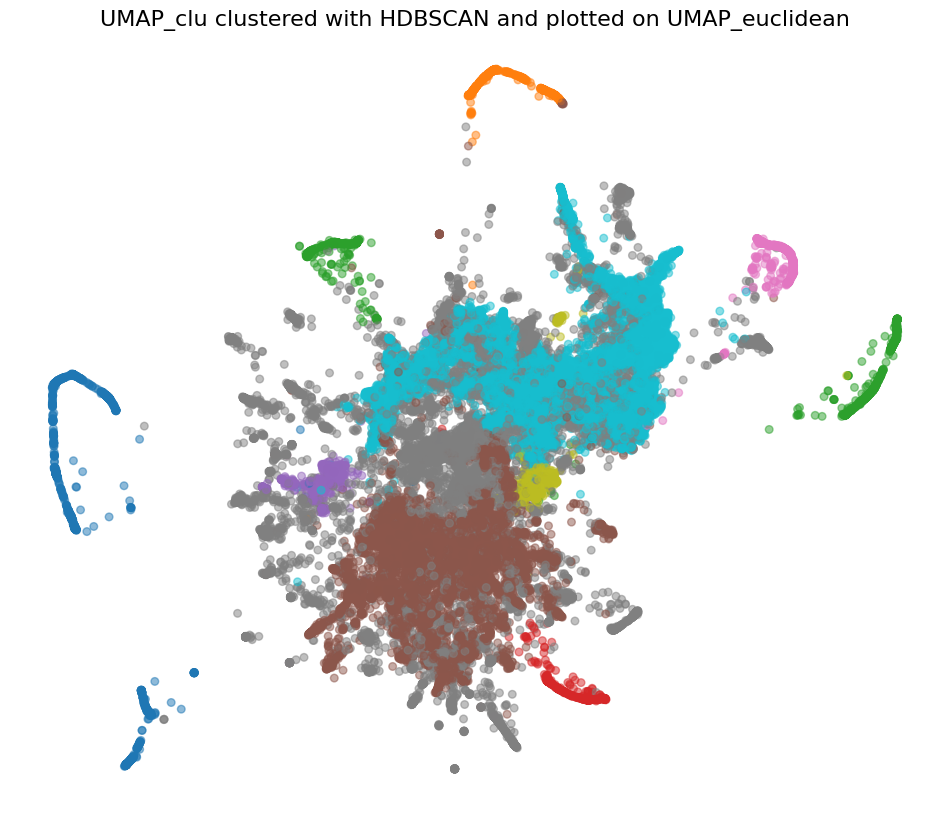

In [ ]:


# Assuming hdbscan_labels and UMAP_euclidean are already defined

# Get unique labels and count clusters (excluding noise)
unique_labels = np.unique(labels_clu)
num_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

# Create a colormap for valid clusters (excluding noise)
cluster_cmap = plt.get_cmap("tab10", num_clusters)  # Change colormap if needed

# Generate colors for clusters, mapping -1 to gray
color_dict = {label: cluster_cmap(i) for i, label in enumerate(unique_labels) if label != -1}
color_dict[-1] = "gray"  # Explicitly assign gray to noise points

# Convert labels to corresponding colors (store as a list instead of NumPy array)
color = [color_dict[label] for label in labels_clu]

# Extract UMAP coordinates
x, y = UMAP_euclidean['UMAP_1'], UMAP_euclidean['UMAP_2']

# Plot the embedding
plt.figure(figsize=(12, 10))

# Scatter plot with colors
plt.scatter(x, y, c=color, s=30, alpha=0.5)

# Set title and labels
plt.title("UMAP_clu clustered with HDBSCAN and plotted on UMAP_euclidean", fontsize=16)
plt.xlabel("UMAP 1", fontsize=14)
plt.ylabel("UMAP 2", fontsize=14)

# Hide axes for a cleaner look
plt.axis('off')

# Show the plot
plt.show()

would be nice to use a silhouette analysis to evaluate the result like in K-Means, but it is better not because:

In HDBSCAN, the persistency score is a more reliable measure of cluster quality than the silhouette score because it directly reflects the hierarchical nature of density-based clustering. Unlike silhouette scores, which assume compact, well-separated clusters and struggle with varying densities, persistency scores quantify how consistently a cluster remains intact throughout different levels of the hierarchy. This means that highly persistent clusters are more stable and meaningful, while low-persistence clusters are likely unreliable. Since HDBSCAN is designed to find clusters of varying shapes and densities, persistency better captures its clustering behavior, making it a more appropriate metric for evaluation.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


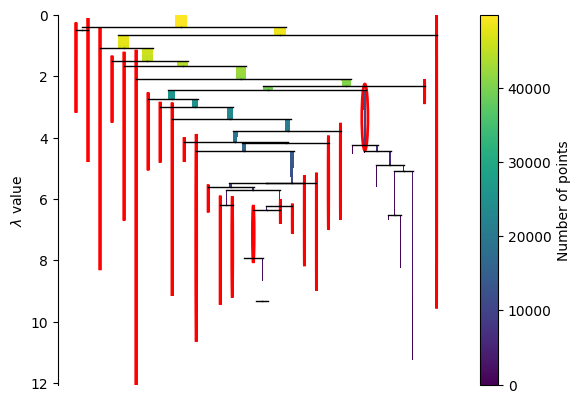

In [ ]:
#persistence can be observed by this plot

features = UMAP_clu.drop(columns=['user_uid', 'cluster']).copy()
# ✅ Ensure you fit HDBSCAN on the data
clusterer = hdbscan.HDBSCAN(min_samples=10,min_cluster_size=400)
clusterer.fit(features)  # <-- Fit the model first!

# ✅ Now plot the condensed tree
clusterer.condensed_tree_.plot(select_clusters=True, selection_palette='deep')
plt.show()

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
features = UMAP_clu.drop(columns=['user_uid', 'cluster']).copy()

hdb = hdbscan.HDBSCAN(min_cluster_size=430,min_samples=4,
                                      cluster_selection_method='eom', metric='euclidean',
                                      gen_min_span_tree=True).fit(features)
score = hdb.relative_validity_

print("DBCV score: {:.3f}".format(score))


DBCV score: 0.148


In [ ]:
# Naive grid search implementation by Mueller and Guido, Introduction to Machine Learning with Python

features = UMAP_clu.drop(columns=['user_uid', 'cluster']).copy()

best_score = 0

for min_cluster_size in [50,75,100,125,150,175,200,225,250,275,300,325,350,375,400]:
    for min_samples in [4,5,6,7,8,9,10,15,20,25,30,35,40,50,60,70,80,90,100,125,150,175,200,250,300,350,400]:
        for cluster_selection_method in ['eom','leaf']:
            for metric in ['euclidean']:
                # for each combination of parameters of hdbscan
                hdb = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,min_samples=min_samples,
                                      cluster_selection_method=cluster_selection_method, metric=metric,
                                      gen_min_span_tree=True).fit(features)
                # DBCV score
                score = hdb.relative_validity_
                # if we got a better DBCV, store it and the parameters
                if score > best_score:
                    best_score = score
                    best_parameters = {'min_cluster_size': min_cluster_size,
                               ' min_samples':  min_samples, 'cluster_selection_method': cluster_selection_method,
                              'metric': metric}

print("Best DBCV score: {:.3f}".format(best_score))
print("Best parameters: {}".format(best_parameters))

Best DBCV score: 0.541
Best parameters: {'min_cluster_size': 350, ' min_samples': 125, 'cluster_selection_method': 'eom', 'metric': 'euclidean'}


In [ ]:
features = UMAP_clu.drop(columns=['user_uid', 'cluster']).copy()

labels_best = hdbscan.HDBSCAN(
    min_samples=125,
    min_cluster_size=350,
).fit_predict(features)


# Count observations in each cluster
cluster_counts = Counter(labels_best)
num_noise_points = cluster_counts[-1] if -1 in cluster_counts else 0

# Print results
print(f"Number of clusters: {np.unique(labels_best).tolist()}")
print(f"Observations per cluster: {dict((k, v) for k, v in cluster_counts.items() if k != -1)}")
print(f"Number of noise points: {num_noise_points}")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Number of clusters: [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
Observations per cluster: {np.int64(19): 4124, np.int64(7): 869, np.int64(15): 666, np.int64(10): 683, np.int64(18): 3477, np.int64(9): 11501, np.int64(16): 1002, np.int64(21): 569, np.int64(1): 424, np.int64(13): 564, np.int64(4): 471, np.int64(14): 1025, np.int64(8): 362, np.int64(12): 2327, np.int64(3): 656, np.int64(0): 575, np.int64(2): 800, np.int64(20): 730, np.int64(5): 605, np.int64(11): 626, np.int64(17): 747, np.int64(6): 468}
Number of noise points: 16563


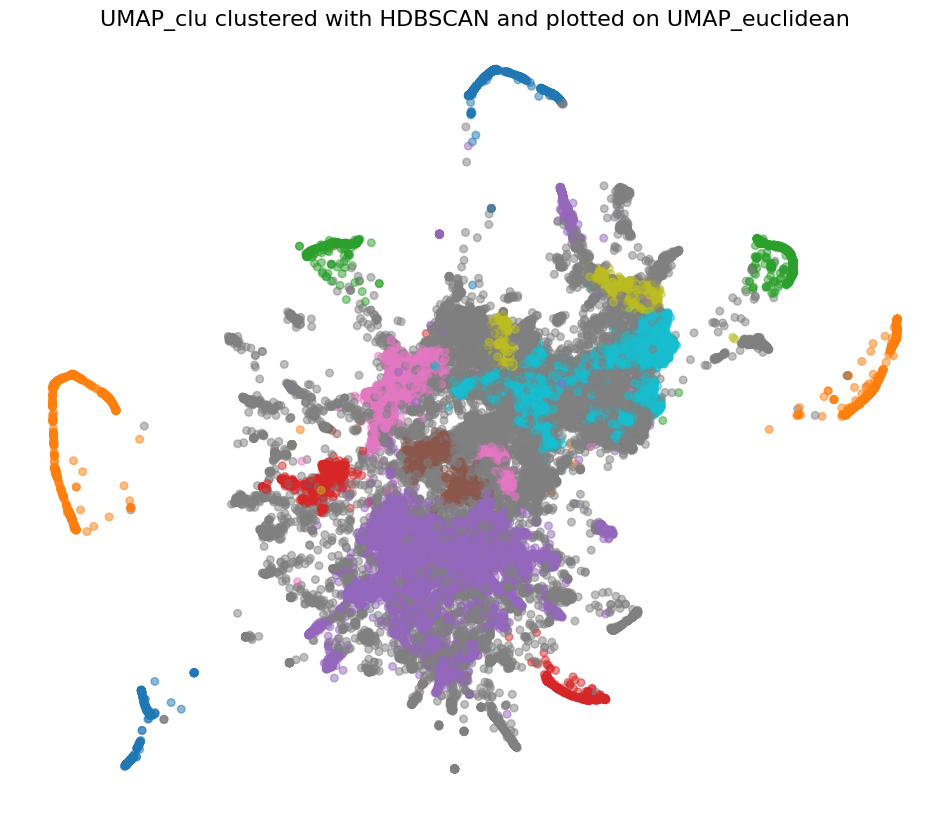

In [ ]:
# Get unique labels and count clusters (excluding noise)
unique_labels = np.unique(labels_best)
num_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

# Create a colormap for valid clusters (excluding noise)
cluster_cmap = plt.get_cmap("tab10", num_clusters)  # Change colormap if needed

# Generate colors for clusters, mapping -1 to gray
color_dict = {label: cluster_cmap(i) for i, label in enumerate(unique_labels) if label != -1}
color_dict[-1] = "gray"  # Explicitly assign gray to noise points

# Convert labels to corresponding colors (store as a list instead of NumPy array)
color = [color_dict[label] for label in labels_best]

# Extract UMAP coordinates
x, y = UMAP_euclidean['UMAP_1'], UMAP_euclidean['UMAP_2']

# Plot the embedding
plt.figure(figsize=(12, 10))

# Scatter plot with colors
plt.scatter(x, y, c=color, s=30, alpha=0.5)

# Set title and labels
plt.title("UMAP_clu clustered with HDBSCAN and plotted on UMAP_euclidean", fontsize=16)
plt.xlabel("UMAP 1", fontsize=14)
plt.ylabel("UMAP 2", fontsize=14)

# Hide axes for a cleaner look
plt.axis('off')

# Show the plot
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


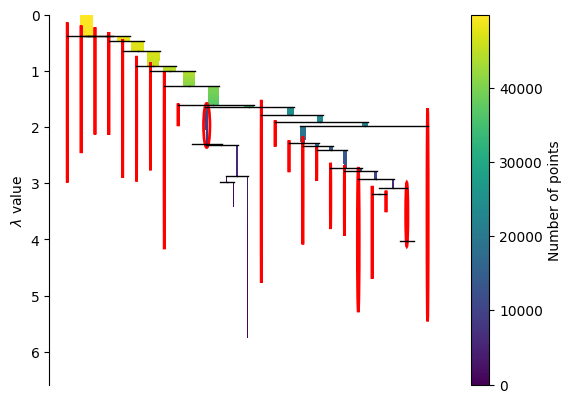

In [ ]:
#persistence can be observed by this plot

features = UMAP_clu.drop(columns=['user_uid', 'cluster']).copy()
# ✅ Ensure you fit HDBSCAN on the data
clusterer = hdbscan.HDBSCAN(min_samples=125,min_cluster_size=350)
clusterer.fit(features)  # <-- Fit the model first!

# ✅ Now plot the condensed tree
clusterer.condensed_tree_.plot(select_clusters=True, selection_palette='deep')
plt.show()